# Local Learning with Spiking Neural Networks: Estimation

# Outline

## 1) Define populations

* **State layer (X)**: $N_x$ LIF neurons with decoder $D\in R^{K\times N_x}$, leak $\lambda$, recurrency $\Omega_s,\Omega_f$, feed-forward weight $F_i$, and yet-to-learn Kalman-gain loop $\Omega_k$.
* **Error layer (E):** $N_e=K$ LIF neurons with decoder $D_e=I_{K\times K}$, leak $\lambda$, recurrency $\Omega_s,\Omega_f$, and a questionable feed-forward weight $F_i$.

---

## 2) Spiking dynamics each timestep

1. **X-layer step**:

   $$
   \dot v_x = -\lambda v_x + \Omega_s\,r_x + \Omega_f\,s_x  + F_i\,u
               + \underbrace{\Omega_k\,r_x + F_k\,r_e}_{\text{from E}}
               + \eta,
   $$

   threshold $\to$ spike $s_x$, update rate $r_x$.
2. **Decode** $\hat x = D\,r_x$.
3. **Compute prediction error** $\;e = y - C\,\hat x\in R^K$.
4. **E-layer step**:

   $$
\dot v_e \;=\; -\lambda v_e
\;+\;\Omega_s^e\,r_e
\;+\;\Omega_f^e\,s_e
\;+\;F_{e,y}\,y
\;+\;F_{e,x}\,r_x
\;+\;\eta_e.
$$ where

$$
F_{e,y}\;=\;D_e^{\!\top}, 
\quad
F_{e,x}\;=\;-\,D_e^{\!\top}\,C\,D
$$


---

## 3) Local, spike-driven plasticity

After each timestep $t$, use the new filtered rates $r_x(t)$, $r_e(t)$ and the fresh spikes $s_x(t)$, $s_e(t)$ to update:

1. **Observation matrix $C$** (X→E synapses):

   $$
     \Delta C_{i j}
     \;=\;\eta_C\;\bigl[r^{(E)}_i(t)\bigr]\;\bigl[r^{(X)}_j(t)\bigr]
   $$
2. **Kalman gain $K_f$** (E→X synapses):

   $$
     \Delta (K_f)_{p i}
     \;=\;\eta_K\;\bigl[r^{(X)}_p(t)\bigr]\;\bigl[r^{(E)}_i(t)\bigr]
   $$

Immediately **recompute** the dependent loops:

$$
\Omega_k = -\,D^\top K_f\,C\,D,\quad
F_k = D^\top K_f.
$$

All other loops ($\Omega_s,\Omega_f,F_i$) remain fixed.

---

## 4) Simulation in this notebook

* **Initialize** with

  * random small $C,K_f$,
  * random-ish $D$ tiling the state‐space,
  * $\Omega_s=D^\top(A+\lambda I)D$, $\Omega_f=-D^\top D$.
* **Run** for a short horizon (e.g. 1 s at dt=1 ms): at each step we do the two-layer spiking update + plasticity above.
* **Plot**

  1. $\hat x(t)$ (from SCN) vs. true $x(t)$ before/after learning.
  2. Evolution of the learned $C$ or $K_f$ toward their analytic values.
  3. A raster of spikes from X and E layers.

# Installations

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# LIF Layer

This `LIFLayer` class models a small population of leaky integrate-and-fire neurons all at once, keeping track of each neuron’s membrane voltage, its recent firing rate, and whether it just spiked.  Every time you call its `step(...)` method, it first computes how the voltages should drift and interact — letting slow recurrent connections push them up, fast resets knock them down when spikes occur, and any external drive nudge them as well — then it adds a bit of random noise, checks which neuron has crossed its individual threshold, fires exactly one spike if any have, and finally updates each neuron’s smoothed firing rate.  The `decode()` method simply multiplies the current firing rates by a fixed decoder matrix to give you the layer’s "guess" of whatever quantity those neurons are representing.  You can use the same class for both your state-coding layer and your error-coding layer by giving it the appropriate decoder matrix and weight matrices at initialization.

In [4]:
class LIFLayer:
    """
    A generic leaky‐integrate‐and‐fire population.

    Attributes:
        N        : int, number of neurons
        lam      : float, leak rate
        D        : ndarray (K x N), decoder matrix
        Omega_s  : ndarray (N x N), slow recurrent weights
        Omega_f  : ndarray (N x N), fast recurrent weights
        F_in     : ndarray (N x M), feed-forward weights (optional)
        T        : ndarray (N,), spike threshold for each neuron
        v        : ndarray (N,), membrane potentials
        r        : ndarray (N,), filtered spike rates
        s        : ndarray (N,), latest spike indicators (0 or 1/dt)
    """
    def __init__(self, N, lam, D, Omega_s, Omega_f, F_in=None, T=None, dt=1e-3):
        self.N = N
        self.lam = lam
        self.D = D
        self.Omega_s = Omega_s
        self.Omega_f = Omega_f
        self.F_in = F_in
        self.dt = dt

        # Thresholds: default to diag(D.T @ D) / 2 as in the paper
        self.T = (np.diag(D.T @ D) / 2.0) if (T is None) else T

        # State variables
        self.v = np.zeros(N)
        self.r = np.zeros(N)
        self.s = np.zeros(N)

    def step(self, input_drive=None, noise_sigma=0.0):
        """
        Advance the layer by one timestep.

        Args:
            input_drive: ndarray (M,) or None, feed-forward input (u for X, e for E)
            noise_sigma: float, standard deviation of voltage noise
        """
        # Compute drive terms
        drive = -self.lam * self.v + self.Omega_s @ self.r - self.Omega_f @ self.s
        if self.F_in is not None and input_drive is not None:
            drive += self.F_in @ input_drive

        # Euler update with optional noise
        self.v += drive * self.dt + np.sqrt(self.dt) * noise_sigma * np.random.randn(self.N)

        # Thresholding: only the neuron with max v may fire (firing the first one)
        above = np.where(self.v > self.T)[0]
        self.s.fill(0.0)
        if above.size > 0:
            k = above[np.argmax(self.v[above])]
            self.s[k] = 1.0 / self.dt  # Dirac approximation

        # Reset is handled implicitly via the fast term in next drive

        # Update filtered rates
        dr = self.s - self.lam * self.r
        self.r += dr * self.dt

    def decode(self):
        """
        Return the decoded output: x_hat = D @ r.
        """
        x_hat = self.D @ self.r
        return x_hat

# Kalman + SCN

The `KalmanSCN` class implements a fully spiking, recurrent Kalman‐filter estimator using two coupled LIF populations. At each timestep it first propagates a "state" population (X) driven by its internal predictive loop, a fast reset loop, an external control input, and a corrective feedback loop derived from the current estimate of the Kalman gain.  It then decodes those spikes into a state estimate $\hat x$.  Simultaneously, an "error" population (E) receives only feed‐forward spikes encoding the raw measurement $y$ and recurrent inhibition from the X‐layer that implements $-C\hat x$, so that its voltages naturally represent the innovation $y - C\hat x$.  Both populations fire irregular, sparse spikes; their filtered rates $r_x$ and $r_e$ are used in two local Hebbian updates ($\Delta C\propto r_e\otimes r_x$ and $\Delta K_f\propto r_x\otimes r_e$) to adapt the observation matrix and Kalman gain on‐the‐fly.  After each plasticity step the code recomputes the Kalman correction loops in the X‐layer so that all operations remain strictly local, spike‐driven, and biologically plausible.

In [36]:
class KalmanSCN:
    """
    A spiking Kalman filter with two LIF populations (state X and error E) that locally learns
    both the observation matrix C and the Kalman gain Kf via Hebbian spike-driven plasticity.

    Attributes:
        A         : ndarray (K x K), state-transition matrix
        B         : ndarray (K x P), control-input matrix
        C         : ndarray (Q x K), observation matrix (learned)
        Kf        : ndarray (K x Q), Kalman gain matrix (learned)
        lam       : float, leak rate
        dt        : float, timestep size
        eta_C     : float, learning rate for C
        eta_K     : float, learning rate for Kf
        X_layer   : LIFLayer, state-coding LIF population
        E_layer   : LIFLayer, error-coding LIF population
    """
    def __init__(self, A, B, C, Kf, D, D_e, lam, dt, eta_C, eta_K):
        # Store system and learning params
        self.A, self.B = A, B
        self.C = C.copy()
        self.Kf = Kf.copy()
        self.lam = lam
        self.dt = dt
        self.eta_C = eta_C
        self.eta_K = eta_K

        # Dimensions
        K, N_x = D.shape
        N_e = K
        
        # Build SCN loops
        # Predictive & fast loops for X
        Omega_s = D.T @ (A + lam*np.eye(K)) @ D  # by def
        Omega_f = -D.T @ D  # by def
        F_i = D.T @ B  # by def
        Omega_k = -D.T @ Kf @ C @ D  # by def
        F_k = D.T @ Kf  # by def
        T = np.diag(D.T @ D) / 2.0  # by def in the paper
        
        # similar loops for E, up to debate
        Omega_s_e = - D_e.T @ (lam*np.eye(Q)) @ D_e # by def
        Omega_f_e = -D_e.T @ D_e  # by def
        F_in_e    = np.hstack([ # NOT BY DEF
            D_e.T,  # maps y (Q,)
           -D_e.T @ self.C @ D  # maps r_x (N_x,)
        ])
        T_e = np.zeros(D_e.shape[1])  # NOT BY DEF
        
        # Instantiate X and E layers
        self.X_layer = LIFLayer(N_x, lam, D, Omega_s, Omega_f, F_in=np.hstack([F_i, F_k]), T=T, dt=dt)
        self.E_layer = LIFLayer(N_e, lam, D_e, Omega_s_e, Omega_f_e, F_in=F_in_e, T=T_e, dt=dt)

    def step(self, u, y):
        """
        Advance the network by one timestep: update state and error layers, apply plasticity.

        Args:
            u : ndarray (P,), control input at current timestep
            y : ndarray (Q,), measurement input at current timestep

        Returns:
            x_hat : ndarray (K,), current state estimate after update
        """
        # State layer update with combined input [u; r_e]
        input_x = np.concatenate([u, self.E_layer.r])
        self.X_layer.step(input_x)
        
        # Decode state estimate
        x_hat = self.X_layer.decode()
        
        # Compute innovation
        e = y - self.C @ x_hat # -> using this to update the Error layer would be cheating, right?
        
        # Error layer update: feed it [y ; r_x] so d = [D_e', -D_e' C D] · [y; r_x]
        input_e = np.concatenate([y, self.X_layer.r])
        self.E_layer.step(input_e)
        
        # Apply plasticity and rebuild loops
        self.update_weights(x_hat)
        self.rebuild_kalman()
        
        return x_hat, e

    def update_weights(self, x_hat):
        """
        Apply local Hebbian updates to the observation matrix C and Kalman gain Kf.
        """
        # Local Hebbian updates
        r_e = self.E_layer.r
        
        self.C += self.eta_C * np.outer(r_e, x_hat)  # ΔC_ij ∝ e_i xhat_j
        self.Kf += self.eta_K * np.outer(x_hat, r_e)  # reasoning: Le ∝ x_hat, and e ∝ r_e

    def rebuild_kalman(self):
        """
        Recompute the Kalman correction loops based on updated C and Kf.
        """
        # Recompute Kalman loops in X_layer
        D = self.X_layer.D
        C, Kf = self.C, self.Kf
        
        Omega_k = -D.T @ Kf @ C @ D
        F_k = D.T @ Kf
        
        # Update X_layer's feedforward matrix [F_i, *F_k*]
        F_i = D.T @ self.B  # static
        self.X_layer.F_in = np.hstack([F_i, F_k])
        # Update X_layer's recurrent slow loop (Omega_s + *Omega_k*)
        Omega_s = D.T @ (self.A + self.lam*np.eye(D.shape[0])) @ D  # static
        self.X_layer.Omega_s = Omega_s + Omega_k

# Simulation

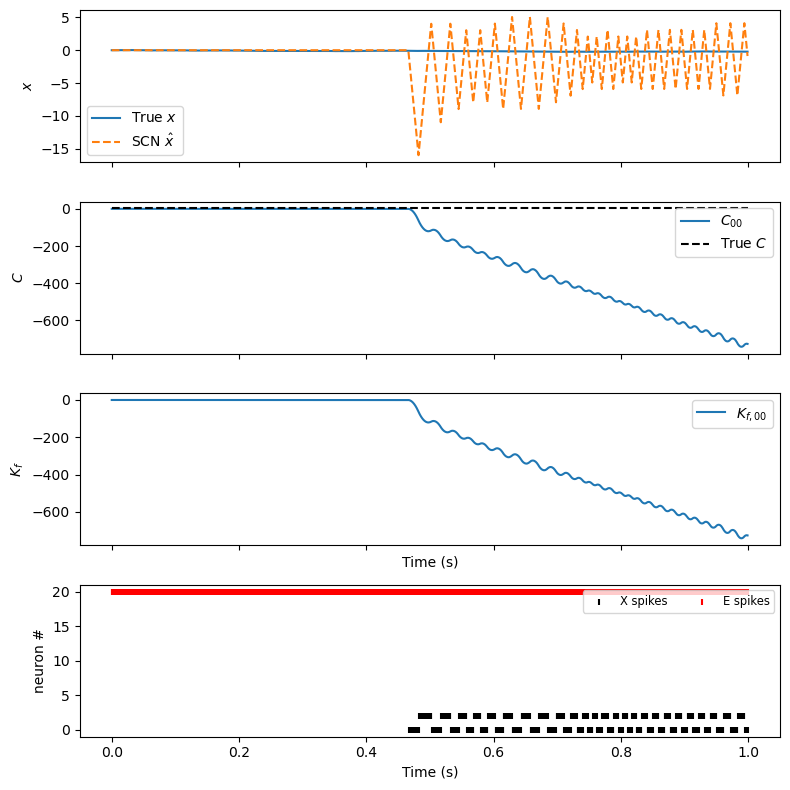

In [60]:
# Dimensions of the toy system:
K = 1  # State dimension (x dim)
P = 0  # Control‐input dimension (no control here) (u dim)
Q = 1  # Measurement dimension (y dim)

# True system matrices:
A = np.array([[0.9]])  # State‐transition scalar (x_{t+1} ≈ 0.9·x_t + noise)
B = np.zeros((K, P))  # No control, so B is (1×0)
C_true = np.array([[2.0]])    # True observation scalar (y_t = 2·x_t + noise)

# Noise levels:
proc_noise = 0.1  # Standard deviation of process noise
sens_noise = 0.1  # Standard deviation of sensor noise

# SCN hyperparameters:
N_x = 20  # Number of neurons in the state‐coding layer
lam = 0.1  # Leak rate λ in each LIF neuron
dt = 1e-3  # Simulation timestep (1 ms)
eta_C = 1e-3  # Learning rate for the observation matrix C
eta_K = 1e-3  # Learning rate for the Kalman gain Kf

# Decoder matrices:
temp_D = np.random.randn(K, N_x)
D = temp_D / np.linalg.norm(temp_D, axis=0)  # Random normalized decoder for X‐layer
D_e = np.eye(Q)  # Identity decoder for E‐layer (shape 1×1)

# Learnable Parameters
C_learn = 0.01 * np.random.randn(*C_true.shape)  # init observation matrix C to small random
Kf_learn = 0.01 * np.random.randn(K, Q)  # init Kalman‐gain Kf to small random

# Initialize the spiking Kalman filter network with zeroed C and Kf:
scn = KalmanSCN(
    A, B,
    C_learn,  # start C at 0
    Kf_learn,  # start Kf at 0
    D, D_e,
    lam, dt,
    eta_C, eta_K
)

# Simulation setup:
T_sim = 1.0 # Total simulation time (seconds)
times = np.arange(0, T_sim, dt)
x = np.zeros(K) # Initial true state x_0 = 0

# Containers for history:
x_hist = []
x_hat_hist = []
C_hist = []
Kf_hist = []
s_x_hist = []
s_e_hist = []

# Run the simulation loop:
for _ in times:
    # 1) True system propagation with process noise and no control:
    x = x + (A @ x) * dt + proc_noise * np.sqrt(dt) * np.random.randn(K)

    # 2) Measurement generation with sensor noise:
    y = C_true @ x + sens_noise * np.random.randn(Q)

    # 3) SCN step: no control input (u is empty), measurement y as spikes
    x_hat, e = scn.step(np.zeros(P), y)

    # 4) Record trajectories and learned weights:
    x_hist.append(x.item())
    x_hat_hist.append(x_hat.item())
    C_hist.append(scn.C.item())
    Kf_hist.append(scn.Kf.item())
    s_x_hist.append(scn.X_layer.s.copy())
    s_e_hist.append(scn.E_layer.s.copy())

# Convert lists to arrays for plotting:
x_hist = np.array(x_hist)
x_hat_hist = np.array(x_hat_hist)
C_hist = np.array(C_hist)
Kf_hist = np.array(Kf_hist)
s_x_hist = np.array(s_x_hist)
s_e_hist = np.array(s_e_hist)

# Plotting the results
fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# Top row: true state vs. SCN estimate
axs[0].plot(times, x_hist, label='True $x$')
axs[0].plot(times, x_hat_hist, '--', label=r'SCN $\hat x$')
axs[0].set_ylabel('$x$')
axs[0].legend()

# Middle row: learned observation matrix C vs. true C_true
axs[1].plot(times, C_hist, label='$C_{00}$')
axs[1].hlines(C_true[0,0], 0, T_sim, colors='k', linestyles='--', label='True $C$')
axs[1].set_ylabel('$C$')
axs[1].legend()

# Bottom row: learned Kalman gain Kf
axs[2].plot(times, Kf_hist, label='$K_{f,00}$')
axs[2].set_ylabel('$K_f$')
axs[2].set_xlabel('Time (s)')
axs[2].legend()

# Bottomest row: spikes from X‐ and E‐layers
raster_x = np.where(s_x_hist > 0)
axs[3].scatter(times[raster_x[0]], raster_x[1], marker='|', s=20, color='black', label='X spikes')
raster_e = np.where(s_e_hist > 0)
axs[3].scatter(times[raster_e[0]], raster_e[1] + N_x, marker='|', s=20, color='red',   label='E spikes')
axs[3].set_ylabel('neuron #')
axs[3].set_xlabel('Time (s)')
axs[3].legend(loc='upper right', ncol=2, fontsize='small')

plt.tight_layout()
plt.show()